In [ ]:
%load_ext autoreload
%autoreload 2
import sys
from scipy.fftpack import dctn, idctn
from csbdeep.utils import normalize

sys.path.append("..")
from src import *

Cupy Available= 1


# Video Fusion With Discrete Fourier Transform (DFT)
Can we augment a denoiser output using a sliding window on the raw footage and DFT video fusion?

This can be used to **reduce the number of training steps for deep-learning models**, which are known to be expensive to train. This is the case with DeepCAD-RT, which uses a 3D UNet.

In [2]:
patch_t = 600
patch_xy = 256
avg_win = 2048
shape_p = (patch_t, patch_xy, patch_xy)

In [10]:
meta = DATASETS["synthetic"]
y_path = DATASETS["synthetic"].dir / "deepcad_E_10.tif"
x, y, gt = (Recording(_, max_frames=2048) for _ in [meta.x, meta.dir / "deepcad_15.tiff", meta.gt])
RES_DIR = mkdir("results/synthetic/")

In [11]:
x_p = x.np[:patch_t, :patch_xy, :patch_xy]
y_hat_p = y.np[:patch_t, :patch_xy, :patch_xy]
gt_p = gt.np[:patch_t, :patch_xy, :patch_xy]
y_bar_p = x.avg_fast(avg_win)[:patch_t, :patch_xy, :patch_xy]

In [ ]:
def norm(arr):
    return np.clip(normalize(arr, 0.25, 99.5), 0, 1)

def make_mask(shape, s0, δs, t0, δt):
    T, H, W = shape
    t = np.arange(T)[:, None, None]
    y = np.arange(H)[None, :, None]
    x = np.arange(W)[None, None, :]

    # normalized ramps in [0,1]
    r = np.sqrt(y**2 + x**2)
    w_s = np.clip((r - (s0 - δs)) / (2 * δs), 0, 1)  # grows from 0→1 around s0
    w_t = np.clip((t - (t0 - δt)) / (2 * δt), 0, 1)  # grows from 0→1 around t0
    return w_s * (1 - w_t)


def fuse_dct(y_bar, y_hat, M):
    Y_bar = dctn(y_bar, type=2, norm="ortho")
    Y_hat = dctn(y_hat, type=2, norm="ortho")
    Y = M * Y_bar + (1 - M) * Y_hat
    return idctn(Y, norm="ortho")

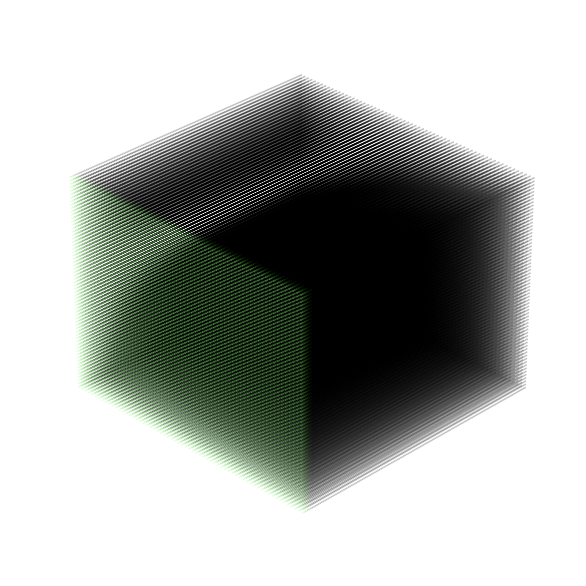

In [27]:
M = make_mask(shape_p, s0=-1, δs=1, t0=12, δt=16)
vidshow(M, dpi=60, step=4)

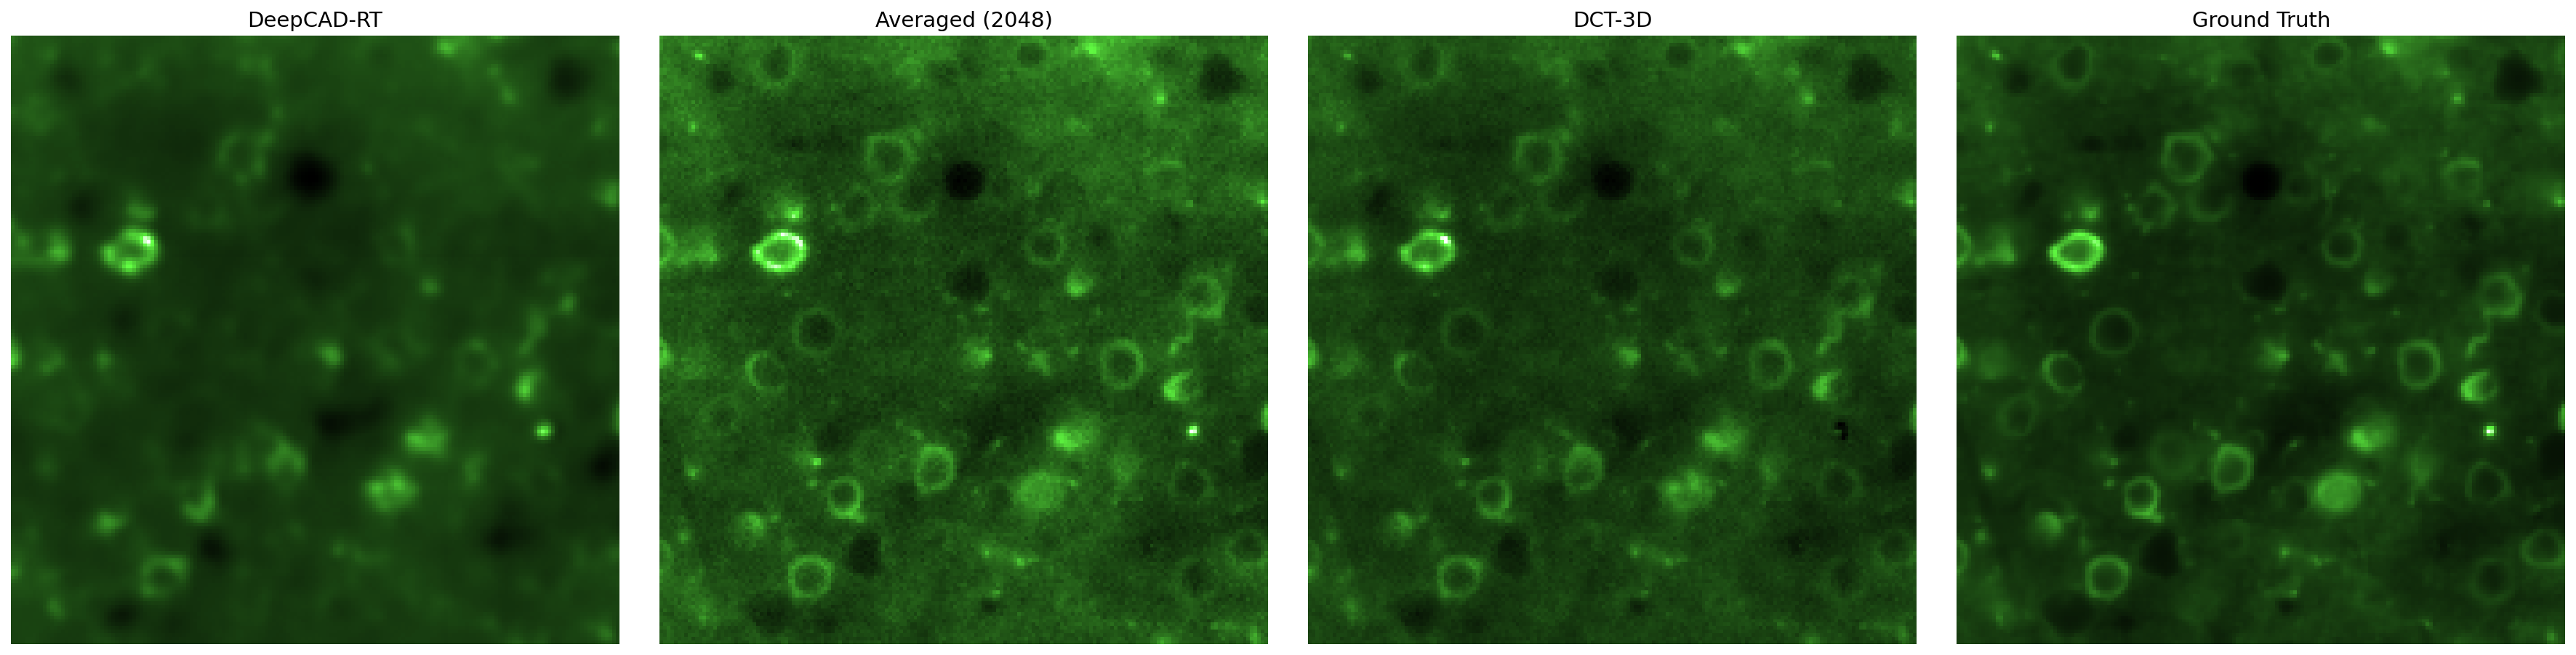

In [12]:
fused = fuse_dct(y_bar_p, y_hat_p, M)
i=100
imshow({
    "DeepCAD-RT":y_hat_p[i],
    f"Averaged ({avg_win})":y_bar_p[i],
    "DCT-3D":fused[i],
    "Ground Truth":gt_p[i],
}, size=6, zoom=1.5)

## $PSNR_{3D}$ and $SSIM_{3D}$ Metrics

In [25]:
psnr3d(norm(y_hat_p), norm(gt_p)), ssim3d(norm(y_hat_p), norm(gt_p))

(np.float64(23.412859427210456), 0.6765005588531494)

In [26]:
psnr3d(norm(fused), norm(gt_p)), ssim3d(norm(fused), norm(gt_p))

(np.float64(22.56960823578773), 0.7409078478813171)

## Temporal analysis

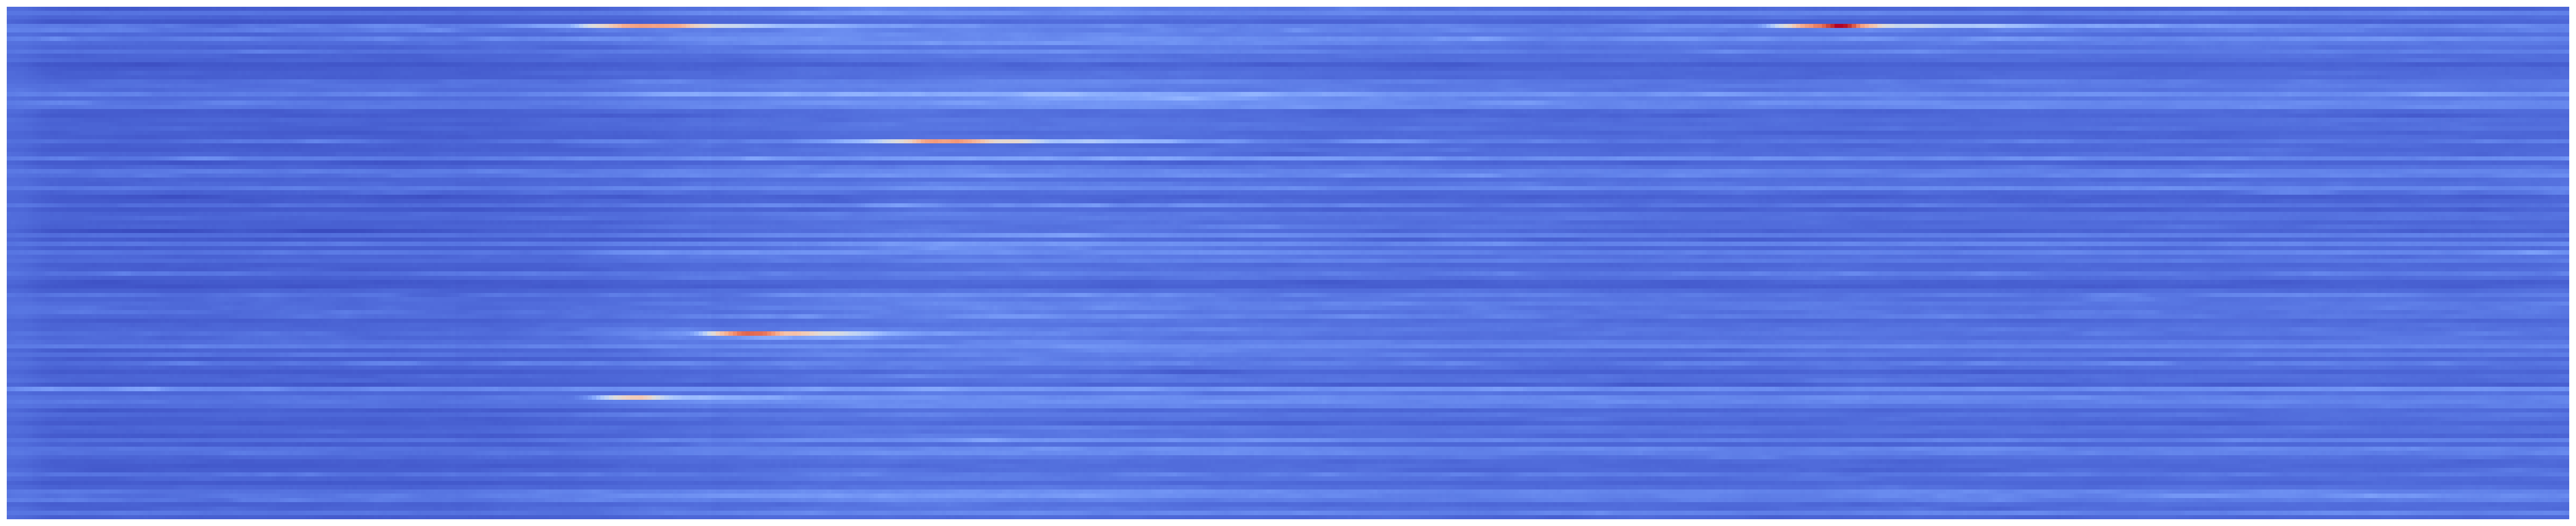

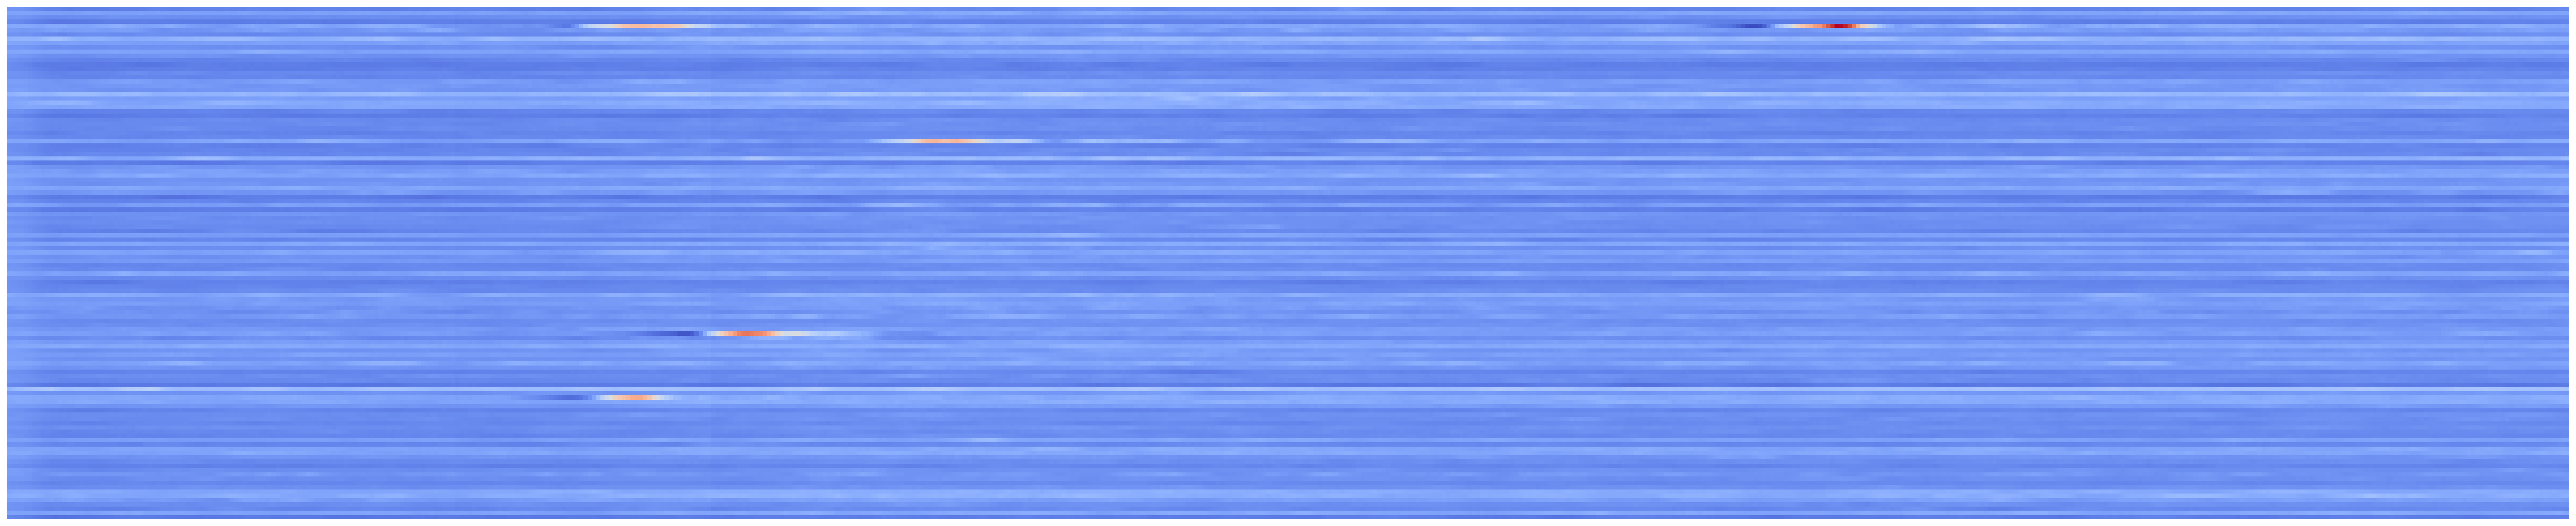

In [31]:
ROIS=120
rois_x = tuple(random.randrange(0, patch_xy) for _ in range(ROIS))
rois_y = tuple(random.randrange(0, patch_xy) for _ in range(ROIS))

imshow(y_hat_p[::1,rois_x, rois_y].T, size=40, cmap="coolwarm")
# imshow(y_bar_p[::2,rois_x, rois_y].T, size=40, cmap="coolwarm")
imshow(fused[::1,rois_x, rois_y].T, size=40, cmap="coolwarm")
# imshow(gt_p[::2,rois_x, rois_y].T, size=40, cmap="coolwarm")